In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

In [2]:
# Load the data and use the first row as the header
data = pd.read_csv("Kanyapella_previous_30_years.csv")

data['avg_temp']=(pd.to_numeric(data['max_temp'])+pd.to_numeric(data['min_temp']))/2

data['daily_rain'] = pd.to_numeric(data['daily_rain'])
data['Date'] = pd.to_datetime(data['YYYY-MM-DD'], format="%d/%m/%Y")

In [3]:
# Create a DataFrame with dates and temperature
df2 = pd.DataFrame({
    'Date': data['Date'],
    'T_value': data['avg_temp'].values
})

# Add day-of-year and year columns
df2['DayOfYear'] = df2['Date'].dt.dayofyear
df2['Year'] = df2['Date'].dt.year

In [4]:
def find_first_day_threshold(df, start_month_day, threshold, n_days, above=True):
    """
    Finds the first date in each year after a given start (month, day) where the n-day average temperature
    exceeds (or falls below) a threshold.

    Parameters:
        df (DataFrame): Must include 'Date' (datetime), 'T_value' (e.g., temperature), and 'Year' columns.
        start_month_day (tuple): Month and day to start from, e.g., (9, 1) for September 1.
        threshold (float): Value threshold to test against.
        n_days (int): Window size for average.
        above (bool): Whether to look for values above or below the threshold.

    Returns:
        DataFrame with Year, Date, and n_day_avg (the average over the window).
    """
    results = []

    for year in df['Year'].unique():
        try:
            start_date = datetime(year, start_month_day[0], start_month_day[1])
        except ValueError:
            continue  # Skip invalid dates like Feb 29 in a non-leap year

        df_year = df[(df['Date'] >= start_date) & (df['Date'].dt.year <= year + 1)].copy()
        df_year = df_year.sort_values('Date').reset_index(drop=True)

        for i in range(n_days - 1, len(df_year)):
            window = df_year.iloc[i - n_days + 1:i + 1]
            avg = window['T_value'].mean()

            if (above and avg > threshold) or (not above and avg < threshold):
                results.append({
                    'Year': year,
                    'Date': df_year.iloc[i]['Date'],
                    'n_day_avg': avg
                })
                break

    return pd.DataFrame(results)

In [5]:
def summer_period(df, spring_start_date, summer_end_date, threshold, n_days, force_first=True):
    """
    Builds summer period ranges including the first period if desired,
    by either checking the n-day average or forcefully assuming it is summer.

    Parameters:
        df (pd.DataFrame): Must include 'Date' (datetime), 'T_value' (float), and 'Year' (int)
        spring_start_date (tuple): (month, day) to start looking for a summer period
        summer_end_date (tuple): (month, day) to start looking for winter threshold
        threshold (float): Threshold value for summer conditions
        n_days (int): Number of days to average
        force_first (bool): If True, forces the first date to be a start of a summer period

    Returns:
        List of (start, end) datetime tuples.
    """
    starts = find_first_day_threshold(df, spring_start_date, threshold=threshold, n_days=n_days, above=True)
    ends = find_first_day_threshold(df, summer_end_date, threshold=threshold, n_days=n_days, above=False)

    summer_periods = []

    # Forced first period but starts part way through so removed later
    if force_first:
        first_valid_end = ends[ends['Date'] > df['Date'].iloc[0]]
        if not first_valid_end.empty:
            end_date = first_valid_end.iloc[0]['Date'] - timedelta(days=1)
            summer_periods.append((df['Date'].iloc[0], end_date))
    else:
        # Check actual n-day average at start
        initial_window = df.iloc[:n_days]
        if len(initial_window) == n_days:
            initial_avg = initial_window['T_value'].mean()
            if initial_avg > threshold:
                first_end = ends[ends['Date'] > df['Date'].iloc[0]]
                if not first_end.empty:
                    end_date = first_end.iloc[0]['Date'] - timedelta(days=1)
                    summer_periods.append((df['Date'].iloc[0], end_date))

    # 🔹 Continue with regular start/end pairing
    for i in range(len(starts)):
        spring_date = starts.loc[i, "Date"]
        year = starts.loc[i, "Year"]

        summer_row = ends[ends["Year"] == year + 1]
        if not summer_row.empty:
            summer_date = summer_row.iloc[0]["Date"] - timedelta(days=1)
            summer_periods.append((spring_date, summer_date))

    return summer_periods

In [6]:
summer_periods = summer_period(df2, (9, 1), (3, 1), threshold=17.5, n_days=4, force_first=True)[1:] # Remove first start of year in 1949 that is not full period

# Rainfall

In [8]:
rainfall_results = []

for _, end in summer_periods:
    july_start = pd.Timestamp(year=end.year - 1, month=7, day=1)

    # Select data between July 1st and the summer period's end date
    rain_sum = data.loc[(data['Date'] >= july_start) & (data['Date'] <= end), 'daily_rain'].sum()
    days = (end - july_start).days + 1 # Inclusive end date

    rainfall_results.append({
        'Start': july_start,
        'End': end,
        'Days': days,
        'Rain_sum': rain_sum,
        'Rain_avg': rain_sum / days
    })

rainfall_summary = pd.DataFrame(rainfall_results)

In [9]:
rainfall_summary['Rain_avg'][0:30].median()

1.2165667808219178

In [10]:
rainfall_summary['Rain_avg'][0:30].quantile(1/3)

1.0844357976653698

In [11]:
rainfall_summary['Rain_avg'][0:30].quantile(2/3)

1.2768350168350167

In [12]:
# Convert Start and End columns in periods to datetime
rainfall_summary['Start'] = pd.to_datetime(rainfall_summary['Start'])
rainfall_summary['End'] = pd.to_datetime(rainfall_summary['End'])

# Initialize a new column in data to hold H_avg
data['R_avg'] = pd.NA

# For each period, assign the period's H_avg to rows in data where date is within that period
for idx, period in rainfall_summary.iterrows():
    mask = (data['Date'] >= period['Start']) & (data['Date'] <= period['End'])
    data.loc[mask, 'R_avg'] = period['Rain_avg']

In [13]:
data['R_avg'] = pd.to_numeric(data['R_avg'], errors='coerce')

# Water Balance

In [15]:
Et = pd.to_numeric(data['et_morton_actual'])

# Get rainfall column
Rain = pd.to_numeric(data['daily_rain'])

# Initialize H
H = [0]

# Calculate H using the formula iteratively
for i in range(1, len(data)):
    H.append(max(0, H[i-1] + Rain[i-1] - Et[i-1]))

# Add result to DataFrame
data['H'] = H

In [16]:
H_results = []

for start, end in summer_periods:
    H_sum = data.loc[(data['Date'] >= start) & (data['Date'] <= end), 'H'].sum()
    H_results.append({
        'Start': start,
        'End': end,
        'Days': (end - start).days + 1, # Inclusive end date
        'H_sum': H_sum,
        'H_avg': H_sum/((end - start).days + 1)
    })

period_H = pd.DataFrame(H_results)

In [17]:
period_H['H_avg'][0:30].median()

13.710067555711506

In [18]:
period_H['H_avg'][0:30].quantile(1/3)

6.094776469327323

In [19]:
period_H['H_avg'][0:30].quantile(2/3)

24.242797202797203

In [20]:
# Convert Start and End columns in periods to datetime
period_H['Start'] = pd.to_datetime(period_H['Start'])
period_H['End'] = pd.to_datetime(period_H['End'])

# Initialize a new column in data to hold H_avg
data['H_avg'] = pd.NA

# For each period, assign the period's H_avg to rows in data where date is within that period
for idx, period in period_H.iterrows():
    mask = (data['Date'] >= period['Start']) & (data['Date'] <= period['End'])
    data.loc[mask, 'H_avg'] = period['H_avg']

In [21]:
data['H_avg'] = pd.to_numeric(data['H_avg'], errors='coerce')

# Combined rainfall and water balance thresholds plot

In [23]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axis lines
    "axes.linewidth": 0.5,

    # Tick thickness
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    # Tick length (optional but helpful)
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Line plots
    "lines.linewidth": 1,

    # Fonts
    "font.family": "Arial",

    # PDF export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

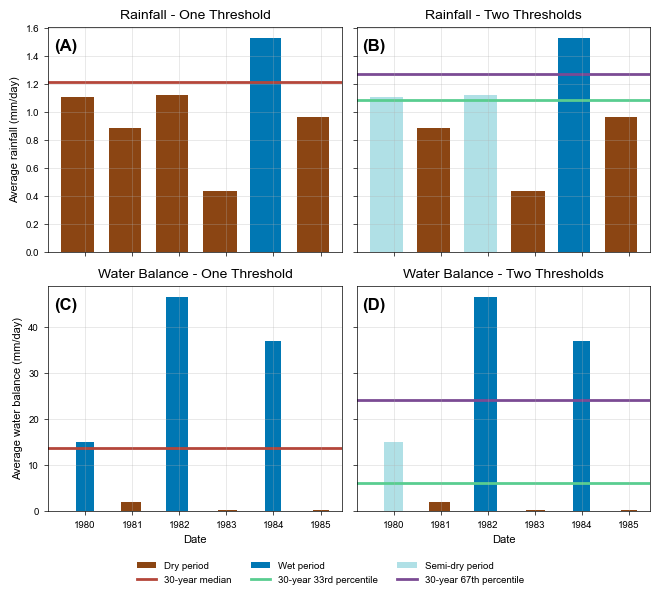

In [24]:
# Data slices
dates = data['Date'][11138:]
rain_vals = data['R_avg'][11138:]
H_vals = data['H_avg'][11138:]

# Thresholds
rain_median = rainfall_summary['Rain_avg'][0:30].median()
rain_thr1 = rainfall_summary['Rain_avg'][0:30].quantile(1/3)
rain_thr2 = rainfall_summary['Rain_avg'][0:30].quantile(2/3)

H_median = period_H['H_avg'][0:30].median()
H_thr1 = period_H['H_avg'][0:30].quantile(1/3)
H_thr2 = period_H['H_avg'][0:30].quantile(2/3)

# Create 2x2 subplot grid with shared y-axis per row
fig_width = 170 / 25.4
fig_height = 150 / 25.4

fig, axes = plt.subplots(
    2, 2,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey='row'
)

# -------------------------
# Rainfall - One Threshold
# -------------------------
colors = ['#0077B3' if val > rain_median else '#8B4513' for val in rain_vals]
axes[0, 0].bar(dates, rain_vals, color=colors, width=1.0, bottom=0, zorder=1)
axes[0, 0].axhline(y=rain_median, color='#B4463A', linewidth=2, zorder=1, label='30-year median')
axes[0, 0].set_ylabel('Average rainfall (mm/day)')
axes[0, 0].set_title('Rainfall - One Threshold')
axes[0, 0].grid(True, linewidth=0.4, alpha = 0.5)
axes[0, 0].tick_params(axis='both')

# -------------------------
# Rainfall - Two Thresholds
# -------------------------
colors = []
for val in rain_vals:
    if val < rain_thr1:
        colors.append('#8B4513')
    elif val > rain_thr2:
        colors.append('#0077B3')
    else:
        colors.append('#B0E0E6')

axes[0, 1].bar(dates, rain_vals, color=colors, width=1.0, bottom=0, zorder=1)
axes[0, 1].axhline(y=rain_thr1, color='#59CD90', linewidth=2, zorder=1, label='33rd percentile')
axes[0, 1].axhline(y=rain_thr2, color='#7B4B94', linewidth=2, zorder=1, label='67th percentile')
axes[0, 1].set_title('Rainfall - Two Thresholds')
axes[0, 1].grid(True, linewidth=0.4, alpha = 0.5)
axes[0, 1].tick_params(axis='both')

# -------------------------
# Water Balance - One Threshold
# -------------------------
colors = ['#0077B3' if val > H_median else '#8B4513' for val in H_vals]
axes[1, 0].bar(dates, H_vals, color=colors, width=1.0, bottom=0, zorder=1)
axes[1, 0].axhline(y=H_median, color='#B4463A', linewidth=2, zorder=1, label='30-year median')
axes[1, 0].set_ylabel('Average water balance (mm/day)')
axes[1, 0].set_title('Water Balance - One Threshold')
axes[1, 0].grid(True, linewidth=0.4, alpha = 0.5)
axes[1, 0].tick_params(axis='both')

# -------------------------
# Water Balance - Two Thresholds
# -------------------------
colors = []
for val in H_vals:
    if val < H_thr1:
        colors.append('#8B4513')
    elif val > H_thr2:
        colors.append('#0077B3')
    else:
        colors.append('#B0E0E6')

axes[1, 1].bar(dates, H_vals, color=colors, width=1.0, bottom=0, zorder=1)
axes[1, 1].axhline(y=H_thr1, color='#59CD90', linewidth=2, zorder=1, label='33rd percentile')
axes[1, 1].axhline(y=H_thr2, color='#7B4B94', linewidth=2, zorder=1, label='67th percentile')
axes[1, 1].set_title('Water Balance - Two Thresholds')
axes[1, 1].grid(True, linewidth=0.4, alpha = 0.5)
axes[1, 1].tick_params(axis='both')

# -------------------------
# X-axis label and formatting
# -------------------------
for ax in axes[1, :]:
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', which='both', top=False, labelbottom=True)

# -------------------------
# Unified Legend
# -------------------------
legend_elements = [
    Patch(facecolor='#8B4513', label='Dry period'),
    Line2D([0], [0], color='#B4463A', lw=2, label='30-year median'),
    Patch(facecolor='#0077B3', label='Wet period'),
    Line2D([0], [0], color='#59CD90', lw=2, label='30-year 33rd percentile'),
    Patch(facecolor='#B0E0E6', label='Semi-dry period'),
    Line2D([0], [0], color='#7B4B94', lw=2, label='30-year 67th percentile')
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=False,
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.95,
    bottom=0.13,
    hspace=0.15,
    wspace=0.05
)
labels = ['A', 'B', 'C', 'D']

for ax, label in zip(axes.flat, labels):
    ax.text(
        0.02, 0.95, f'({label})',   # position in axes coords
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.show()